# Préparation du df

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

pd.set_option('display.max_columns', None)
df_northern = pd.read_csv(filepath_or_buffer = './data/NH.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)

In [81]:
df_northern.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.37,-0.53,-0.24,-0.31,-0.07,-0.18,-0.20,-0.28,-0.25,-0.33,-0.44,-.41,-.30,***,***,-0.21,-0.22,-0.34
1,1881,-0.31,-0.23,-0.04,0.00,0.03,-0.34,0.07,-0.05,-0.27,-0.44,-0.37,-.24,-.18,-.20,-.32,-0.01,-0.11,-0.36
2,1882,0.26,0.21,0.01,-0.32,-0.25,-0.31,-0.29,-0.16,-0.25,-0.53,-0.33,-.68,-.22,-.18,.08,-0.19,-0.25,-0.37
3,1883,-0.58,-0.66,-0.16,-0.29,-0.24,-0.13,-0.04,-0.23,-0.33,-0.16,-0.42,-.15,-.28,-.33,-.64,-0.23,-0.13,-0.30
4,1884,-0.17,-0.09,-0.63,-0.60,-0.37,-0.43,-0.40,-0.50,-0.45,-0.45,-0.58,-.48,-.43,-.40,-.14,-0.53,-0.44,-0.49


In [82]:
df_northern.sort_values(by=['Year'], ascending=False).head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
145,2025,1.83,1.63,1.83,1.58,1.21,1.18,1.22,1.26,1.41,1.47,1.69,***,***,1.50,1.72,1.54,1.22,1.52
144,2024,1.67,1.92,1.77,1.79,1.44,1.54,1.41,1.42,1.56,1.73,1.88,1.70,1.65,1.67,1.81,1.67,1.46,1.72
143,2023,1.29,1.28,1.64,1.02,1.13,1.19,1.44,1.57,1.68,1.87,1.97,1.85,1.49,1.43,1.21,1.26,1.40,1.84
142,2022,1.24,1.16,1.40,1.08,1.02,1.13,1.06,1.17,1.15,1.31,1.09,1.06,1.16,1.17,1.19,1.17,1.12,1.19
141,2021,1.25,0.94,1.20,1.12,1.05,1.21,1.07,1.02,1.04,1.29,1.29,1.16,1.14,1.14,1.12,1.12,1.10,1.21


In [83]:
df_northern.describe()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,MAM,JJA,SON
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,1952.500000,0.103699,0.119178,0.146438,0.113836,0.101849,0.097877,0.098904,0.086096,0.105685,0.158151,0.145137,0.120753,0.095274,0.136233
std,42.290661,0.606639,0.606415,0.599204,0.516937,0.444685,0.444108,0.424958,0.455109,0.466197,0.502385,0.546034,0.509078,0.436543,0.494606
min,1880.000000,-1.510000,-0.960000,-0.810000,-0.670000,-0.750000,-0.530000,-0.600000,-0.780000,-0.820000,-0.860000,-0.820000,-0.720000,-0.550000,-0.740000
25%,1916.250000,-0.290000,-0.342500,-0.250000,-0.260000,-0.227500,-0.180000,-0.177500,-0.210000,-0.217500,-0.180000,-0.225000,-0.237500,-0.200000,-0.197500
50%,1952.500000,0.040000,-0.015000,0.010000,0.010000,0.005000,-0.030000,-0.020000,-0.015000,-0.020000,0.050000,0.050000,-0.005000,-0.025000,0.025000
75%,1988.750000,0.420000,0.497500,0.435000,0.320000,0.255000,0.247500,0.250000,0.257500,0.275000,0.357500,0.347500,0.307500,0.227500,0.280000
max,2025.000000,1.830000,1.930000,1.880000,1.790000,1.440000,1.540000,1.440000,1.570000,1.680000,1.870000,1.970000,1.670000,1.460000,1.840000


In [84]:
# Affichage nb lignes et colonnes
df_northern.shape

(146, 19)

In [85]:
# Affichage des types de chaque colonne
df_northern.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun     float64
Jul     float64
Aug     float64
Sep     float64
Oct     float64
Nov     float64
Dec      object
J-D      object
D-N      object
DJF      object
MAM     float64
JJA     float64
SON     float64
dtype: object

# Nettoyage des données

In [86]:
# Calcul du nombre de doublons
df_northern.duplicated().sum()

np.int64(0)

In [87]:
# Nombre de valeurs uniques dans une colonne :
df_northern['Dec'] = df_northern['Dec'].fillna(0)

print('Dec', df_northern['Dec'].isna().sum(axis = 0))

Dec 0


In [88]:
# Remplacement des données type string par des valeurs nulles et modification du type des colonnes par float

df_northern['Dec'] = df_northern['Dec'].replace(to_replace = "***", value = None)
df_northern['Dec'] = df_northern['Dec'].astype(float)
df_northern['J-D'] = df_northern['J-D'].replace(to_replace = "***", value = None)
df_northern['J-D'] = df_northern['J-D'].astype(float)
df_northern['D-N'] = df_northern['D-N'].replace(to_replace = "***", value = None)
df_northern['D-N'] = df_northern['D-N'].astype(float)
df_northern['DJF'] = df_northern['DJF'].replace(to_replace = "***", value = None)
df_northern['DJF'] = df_northern['DJF'].astype(float)

# Affichage du df

In [89]:
# Affichage du df selon ordre ascendant ou descendant d'une colonne
df_northern.sort_values(by=['Year'], ascending=False).head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
145,2025,1.83,1.63,1.83,1.58,1.21,1.18,1.22,1.26,1.41,1.47,1.69,NaN,NaN,1.50,1.72,1.54,1.22,1.52
144,2024,1.67,1.92,1.77,1.79,1.44,1.54,1.41,1.42,1.56,1.73,1.88,1.70,1.65,1.67,1.81,1.67,1.46,1.72
143,2023,1.29,1.28,1.64,1.02,1.13,1.19,1.44,1.57,1.68,1.87,1.97,1.85,1.49,1.43,1.21,1.26,1.40,1.84
142,2022,1.24,1.16,1.40,1.08,1.02,1.13,1.06,1.17,1.15,1.31,1.09,1.06,1.16,1.17,1.19,1.17,1.12,1.19
141,2021,1.25,0.94,1.20,1.12,1.05,1.21,1.07,1.02,1.04,1.29,1.29,1.16,1.14,1.14,1.12,1.12,1.10,1.21


In [90]:
df_northern.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun     float64
Jul     float64
Aug     float64
Sep     float64
Oct     float64
Nov     float64
Dec     float64
J-D     float64
D-N     float64
DJF     float64
MAM     float64
JJA     float64
SON     float64
dtype: object

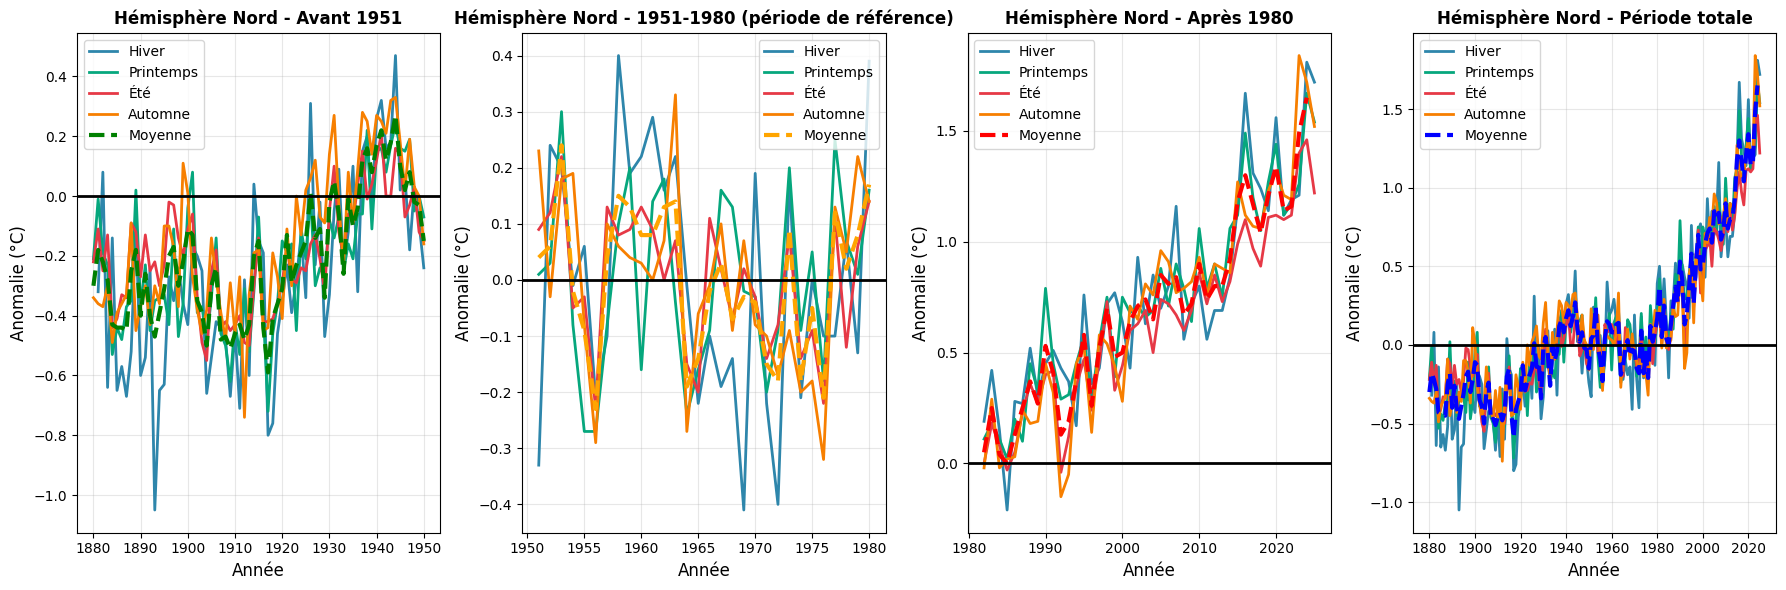

In [91]:
# Comparaison Avant / période de référence / Après pour l'hémisphère Nord

# Séparer les données en trois périodes
df_avant = df_northern[df_northern['Year'] < 1951]   # Années avant 1951
df_pendant = df_northern[df_northern['Year'].between(1951, 1980)]   # Années entre 1951 et 1980
df_apres = df_northern[df_northern['Year'] > 1981]  # Années à partir de 1981

# Quatre graphiques côte à côte
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Graphique de gauche avant 1951
ax1 = axes[0]

# 4 saisons + moyenne
ax1.plot(df_avant['Year'], df_avant['DJF'], label='Hiver', linewidth=2, color='#2E86AB')
ax1.plot(df_avant['Year'], df_avant['MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax1.plot(df_avant['Year'], df_avant['JJA'], label='Été', linewidth=2, color='#E63946')
ax1.plot(df_avant['Year'], df_avant['SON'], label='Automne', linewidth=2, color='#F77F00')
ax1.plot(df_avant['Year'], df_avant['J-D'], label='Moyenne', linewidth=3, color='green', linestyle='--')

# ligne à 0 pour référence
ax1.axhline(0, color='black', linewidth=2, alpha=1)

# Titres et labels
ax1.set_title('Hémisphère Nord - Avant 1951', fontsize=12, fontweight='bold')
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Anomalie (°C)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Graphique central période de référence (1951-1980)
ax2 = axes[1]

# 4 saisons + moyenne
ax2.plot(df_pendant['Year'], df_pendant['DJF'], label='Hiver', linewidth=2, color='#2E86AB')
ax2.plot(df_pendant['Year'], df_pendant['MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax2.plot(df_pendant['Year'], df_pendant['JJA'], label='Été', linewidth=2, color='#E63946')
ax2.plot(df_pendant['Year'], df_pendant['SON'], label='Automne', linewidth=2, color='#F77F00')
ax2.plot(df_pendant['Year'], df_pendant['J-D'], label='Moyenne', linewidth=3, color='orange', linestyle='--')

#ligne à 0 pour référence
ax2.axhline(0, color='black', linewidth=2, alpha=1)


#Titres et labels
ax2.set_title('Hémisphère Nord - 1951-1980 (période de référence)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Anomalie (°C)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

#Graphique de droite après 1980
ax3 = axes[2]

# 4 saisons + moyenne
ax3.plot(df_apres['Year'], df_apres['DJF'], label='Hiver', linewidth=2, color='#2E86AB')
ax3.plot(df_apres['Year'], df_apres['MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax3.plot(df_apres['Year'], df_apres['JJA'], label='Été', linewidth=2, color='#E63946')
ax3.plot(df_apres['Year'], df_apres['SON'], label='Automne', linewidth=2, color='#F77F00')
ax3.plot(df_apres['Year'], df_apres['J-D'], label='Moyenne', linewidth=3, color='red', linestyle='--')

#ligne à 0 pour référence
ax3.axhline(0, color='black', linewidth=2, alpha=1)

#Titres et labels
ax3.set_title('Hémisphère Nord - Après 1980', fontsize=12, fontweight='bold')
ax3.set_xlabel('Année', fontsize=12)
ax3.set_ylabel('Anomalie (°C)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

#Graphique global (période complète)
ax4 = axes[3]

# 4 saisons + moyenne
ax4.plot(df_northern['Year'], df_northern['DJF'], label='Hiver', linewidth=2, color='#2E86AB')
ax4.plot(df_northern['Year'], df_northern['MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax4.plot(df_northern['Year'], df_northern['JJA'], label='Été', linewidth=2, color='#E63946')
ax4.plot(df_northern['Year'], df_northern['SON'], label='Automne', linewidth=2, color='#F77F00')
ax4.plot(df_northern['Year'], df_northern['J-D'], label='Moyenne', linewidth=3, color='blue', linestyle='--')

#ligne à 0 pour référence
ax4.axhline(0, color='black', linewidth=2, alpha=1)

#Titres et labels
ax4.set_title('Hémisphère Nord - Période totale', fontsize=12, fontweight='bold')
ax4.set_xlabel('Année', fontsize=12)
ax4.set_ylabel('Anomalie (°C)', fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('./images/comparaison_avant_apres_periode_reference.png', dpi=300, bbox_inches='tight')
plt.show()

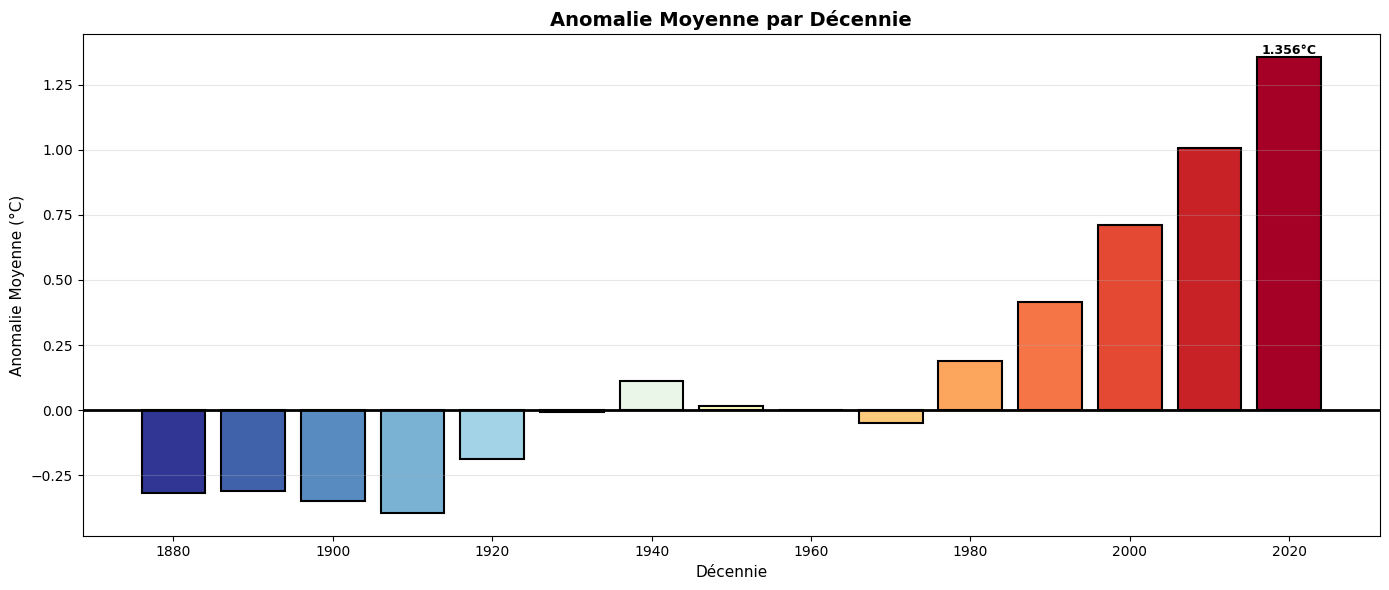

In [92]:
# Anomalie Moyenne par Décennie

# Colonne "Décennie" 
df_northern['Decade'] = (df_northern['Year'] // 10) * 10

# Calcul de la moyenne par décennie
decade_means = df_northern.groupby('Decade')['J-D'].mean()


fig, ax = plt.subplots(figsize=(14, 6))

# Graphique en barres
decades = decade_means.index  # Les décennies (1880, 1890, ...)
values = decade_means.values  # Les anomalies moyennes par décennie

# Dégradé de couleurs (bleu froid → rouge chaud)
n_decades = len(decades)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, n_decades))

# Dessiner les barres
bars = ax.bar(decades, values, width=8, color=colors, 
edgecolor='black', linewidth=1.5)

# Valeurs au-dessus des barres
for bar in bars:
 height = bar.get_height()
ax.text(bar.get_x() + bar.get_width()/2, height,
f'{height:.3f}°C', 
ha='center', va='bottom', fontsize=9, fontweight='bold')

# Une ligne horizontale à 0
ax.axhline(0, color='black', linewidth=2, alpha=1)

# Titres et labels
ax.set_title('Anomalie Moyenne par Décennie', fontsize=14, fontweight='bold')
ax.set_xlabel('Décennie', fontsize=11)
ax.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig('./images/anomalie_par_decennie.png', dpi=300, bbox_inches='tight')
plt.show()


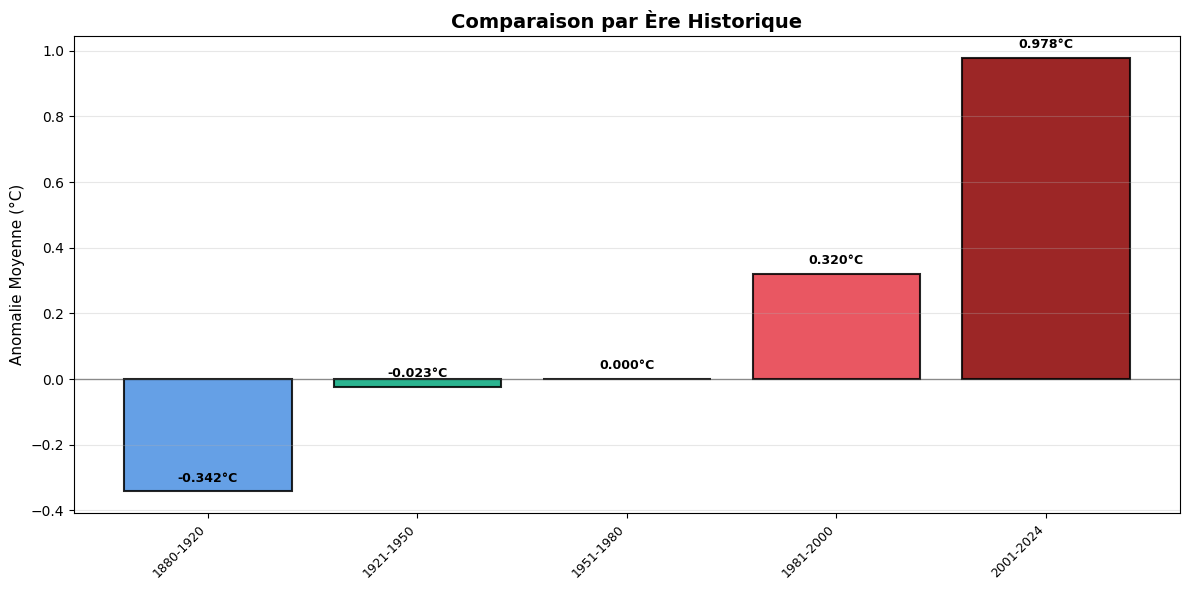

In [93]:
#Comparaison par période historique

#périodes à comparer
periodes = [
    ('1880-1920', 1880, 1920, '#4A90E2'),
    ('1921-1950', 1921, 1950, '#06A77D'),
    ('1951-1980', 1951, 1980, '#F77F00'),
    ('1981-2000', 1981, 2000, '#E63946'),
    ('2001-2024', 2001, 2024, '#8B0000')
]

#Calcule de la moyenne pour chaque période
labels = []       # Noms des périodes
moyennes = []     # Anomalies moyennes
couleurs = []     # Couleurs

for nom, debut, fin, couleur in periodes:
    #>Filtrer les données pour cette période
    donnees_periode = df_northern[(df_northern['Year'] >= debut) & (df_northern['Year'] <= fin)]['J-D']
    
    #>Calculer la moyenne
    moyenne = donnees_periode.mean()
    
    #>Stocker les résultats
    labels.append(nom)
    moyennes.append(moyenne)
    couleurs.append(couleur)

# graphique
fig, ax = plt.subplots(figsize=(12, 6))

positions = range(len(labels))  # 0, 1, 2, 3, 4
bars = ax.bar(positions, moyennes, color=couleurs, 
              edgecolor='black', linewidth=1.5, alpha=0.85)

#Ajouter les valeurs au-dessus des barres
for i, (bar, valeur) in enumerate(zip(bars, moyennes)):
    hauteur = bar.get_height()
    ax.text(i, hauteur + 0.02, f'{valeur:.3f}°C',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

#Ajouter une ligne à 0
ax.axhline(0, color='black', linewidth=1, alpha=0.4)

#Personnaliser les axes
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
ax.set_title('Comparaison par Ère Historique', fontsize=14, fontweight='bold')
ax.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig('./images/comparaison_periodes.png', dpi=300, bbox_inches='tight')
plt.show()


In [94]:
from scipy.stats import linregress

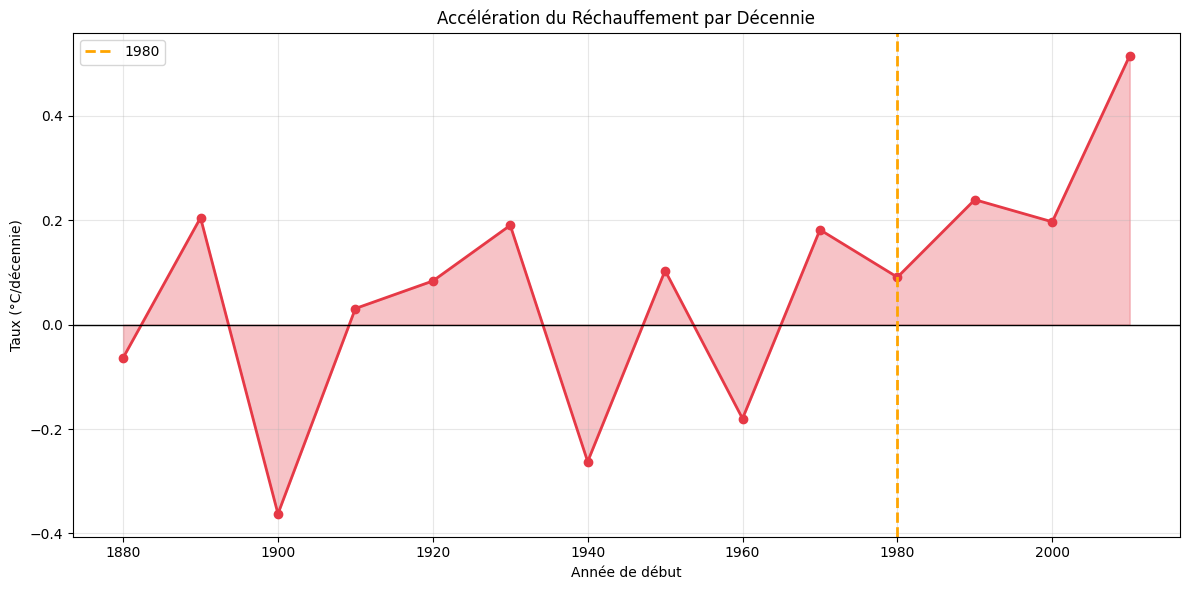

In [95]:
# Accélération du réchauffement

# 1. Calculer le taux de réchauffement pour chaque décennie
periodes = []  # Années de début (1880, 1890, 1900, ...)
taux = []      # Taux de réchauffement (°C par décennie)

for annee_debut in range(1880, 2015, 10):
    # Prendre 10 ans de données
    annee_fin = annee_debut + 10
    donnees = df_northern[(df_northern['Year'] >= annee_debut) & (df_northern['Year'] < annee_fin)]
    
    # Calculer la tendance si on a assez de données
    if len(donnees) >= 5:
        slope, _, _, _, _ = linregress(donnees['Year'], donnees['J-D'])
        periodes.append(annee_debut)
        taux.append(slope * 10)  # Convertir en °C/décennie

#Créer le graphique
fig, ax = plt.subplots(figsize=(12, 6))

#Tracer la courbe
ax.plot(periodes, taux, marker='o', linewidth=2, markersize=6, color='#E63946')

#Ajouter des lignes de référence
ax.axhline(0, color='black', linewidth=1)           # Ligne à 0
ax.axvline(1980, color='orange', linewidth=2, 
           linestyle='--', label='1980')            # Année charnière

#Remplir sous la courbe
ax.fill_between(periodes, taux, 0, alpha=0.3, color='#E63946')

#Titres et labels
ax.set_title('Accélération du Réchauffement par Décennie', fontsize=12)
ax.set_xlabel('Année de début', fontsize=10)
ax.set_ylabel('Taux (°C/décennie)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

#Afficher
plt.tight_layout()
plt.show()


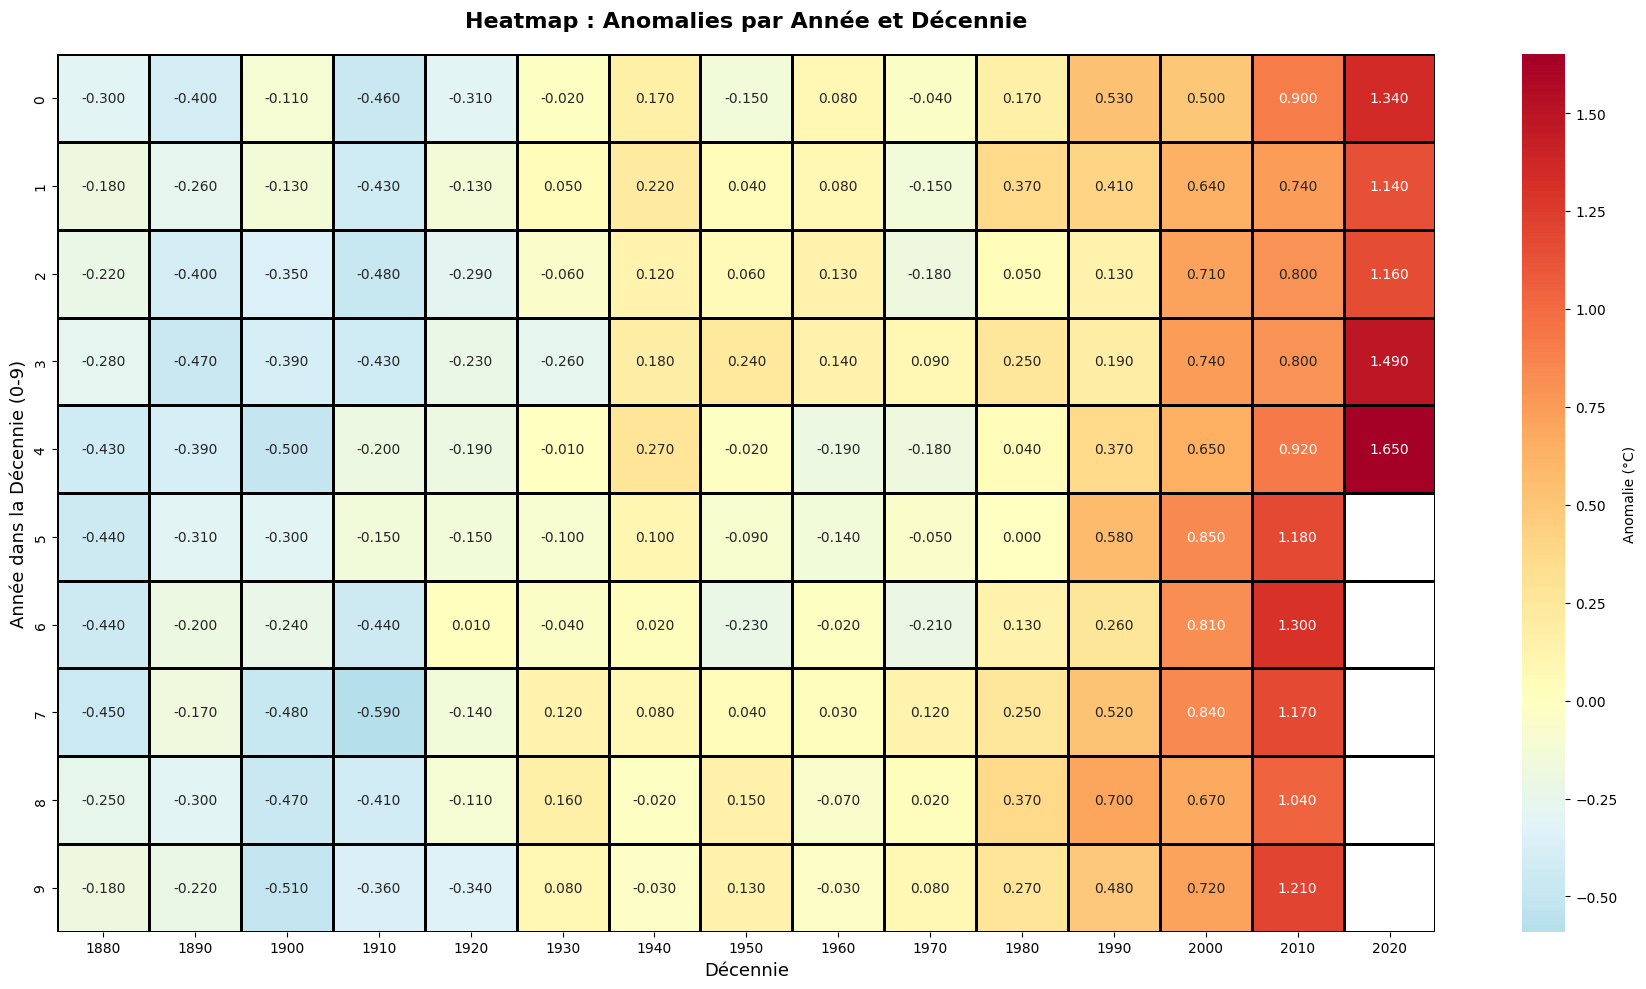

In [96]:
#HEATMAP par année et décennie
fig2, ax = plt.subplots(figsize=(18, 10))

#matrice année x décennie
df_northern['Decade'] = (df_northern['Year'] // 10) * 10
df_northern['YearInDecade'] = df_northern['Year'] % 10

pivot_data = df_northern.pivot_table(values='J-D', index='YearInDecade', columns='Decade', aggfunc='mean')

sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
center=0, linewidths=1, linecolor='black', 
cbar_kws={'label': 'Anomalie (°C)'}, ax=ax)

ax.set_title('Heatmap : Anomalies par Année et Décennie', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Décennie', fontsize=13)
ax.set_ylabel('Année dans la Décennie (0-9)', fontsize=13)

plt.tight_layout()
plt.savefig('./images/heatmap_temperature.png', dpi=300, bbox_inches='tight')
plt.show()

